# BDGDM quickstart

BDGDM is a Bayesian model for estimating the relationship between copy number and gene expression across tumour samples.

This tutorial demonstrates how to:
1. load an example dataset;
2. inspect copy-number coverage for one gene;
3. fit the single-group BDGDM model;
4. examine posterior estimates and model diagnostics;
5. perform posterior predictive checks;
6. classify the gene-dosage response.

The example uses tumour samples only, no matched normal samples are required.

## Input data

BDGDM expects one row per sample and gene, with the following variables:

| Column | Description |
|---|---|
| `gene` | Gene identifier |
| `sampleID` | Unique tumour-sample identifier |
| `expr` | Raw RNA-seq count |
| `copies` | Absolute copy number |
| `subtype` | Optional biological subtype |
| `purity` | Tumour purity between 0 and 1 |
| `sf` | RNA-seq library-size factor |

A dataset containing one subtype invokes the single-group model. 
A dataset containing two or more subtypes invokes the subtype-comparison model.

In [1]:
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel

import bdgdm
from bdgdm import  BDGDMConfig, load_example_data, fit_one_gene_bdgdm, classify
from bdgdm.preprocessing import prepare_gene_data
from bdgdm.posterior import  get_posterior_summary_single
from bdgdm.diagnostics import  get_nuts_diagnostics
from bdgdm.plot_fit import plot_ppc_density
from bdgdm.classify import ClassificationThresholds, classify_fit
from bdgdm import plot_classification 
from bdgdm.classify import get_subtype_classification,  get_transition_classification, get_transition_df

import arviz as az
import xarray as xr
   
pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 3)

In [2]:
print("BDGDM version:", bdgdm.__version__)
print("Python version:", platform.python_version())

BDGDM version: 0.1.0
Python version: 3.11.7


## Load the example dataset

The example dataset is distributed with BDGDM so that the tutorial can be executed without downloading external data.

In [5]:
data = load_example_data()

print("Rows:", len(data))
print("Genes:", data["gene"].nunique())
print("Samples:", data["sampleID"].nunique())

data.head()

Rows: 104516
Genes: 106
Samples: 986


,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.170
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971


## Select one gene and one tumour group

We use a single gene and a single subtype so that BDGDM selects the single-group model.
A gene should have:
- reasonable expression;
- enough tumour samples;
- enough copy-number-altered samples

### Calculate CN variability within the selected subtype to select representative gene.

In [7]:
subtype = "MSS"

cn_variability = (
    data.loc[data["subtype"].eq(subtype)]
    .groupby("gene", as_index=False)
    .agg(
        cn_sd=("copies", "std"),
        cn_variance=("copies", "var"),
        cn_range=("copies", lambda x: x.max() - x.min()),
        n_cn_states=("copies", "nunique"),
        n_samples=("sampleID", "nunique"),
        mean_expr=("expr", "mean"),
    )
    .sort_values(
        ["cn_sd", "n_cn_states"],
        ascending=[False, False],
    )
)

cn_variability.head(10)

,gene,cn_sd,cn_variance,cn_range,n_cn_states,n_samples,mean_expr
41,ERBB2,0.950,0.902,7,6,778,10473.333
86,SLC46A3,0.881,0.776,6,7,778,1201.821
11,ASXL1,0.808,0.652,6,7,778,4839.377
33,CSF3,0.760,0.578,7,7,778,102.274
48,GNAS,0.717,0.514,4,5,778,24628.549
84,SKA3,0.692,0.479,5,6,778,1024.165
53,KLF5,0.685,0.469,6,6,778,17886.440
87,SMAD2,0.574,0.329,7,5,778,4441.992
72,RBM10,0.525,0.276,7,6,778,2151.093
89,SMAD4,0.524,0.275,3,4,778,1971.068


In [9]:
# Select a gene as example

gene = "ASXL1"
subtype = "MSS"

gene_df = (
    data.loc[
        data["gene"].eq(gene)
        & data["subtype"].eq(subtype)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Gene:", gene)
print("Subtype:", subtype)
print("Samples:", len(gene_df))
print("Observed CN states:", sorted(gene_df["copies"].unique()))

gene_df.head()

Gene: ASXL1
Subtype: MSS
Samples: 778
Observed CN states: [2, 3, 4, 5, 6, 7, 8]


,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ASXL1,CRC.SW.U0001.T,9578,4,MSS,0.41,3.8,1.293
1,ASXL1,CRC.SW.U0002.T,6899,3,MSS,0.37,3.3,1.024
2,ASXL1,CRC.SW.U0004.T,7049,4,MSS,0.58,3.2,1.170
3,ASXL1,CRC.SW.U0030.T,5707,3,MSS,0.59,2.2,1.290
4,ASXL1,CRC.SW.U0066.T,5014,2,MSS,0.41,1.9,0.971


### Check CN-state coverage

BDGDM estimates the CN response from variation across tumour samples. A gene observed almost exclusively at CN = 2 contains little
information about dosage sensitivity.

The number of samples in each copy-number state should therefore be examined before model fitting. Rare states may produce broad posterior intervals even when the fitted effect is large.

In [11]:
cn_summary = (
    gene_df.groupby("copies", as_index=False)
    .agg(
        n_samples=("sampleID", "nunique"),
        mean_count=("expr", "mean"),
        median_count=("expr", "median"),
        mean_purity=("purity", "mean"),
    )
)
cn_summary

,copies,n_samples,mean_count,median_count,mean_purity
0,2,300,3506.213,3479.0,0.465
1,3,364,5077.846,4954.0,0.498
2,4,89,7161.629,7151.0,0.540
3,5,20,8898.150,8858.5,0.619
4,6,3,8065.333,9064.0,0.657
5,7,1,12329.000,12329.0,0.620
6,8,1,12962.000,12962.0,0.400


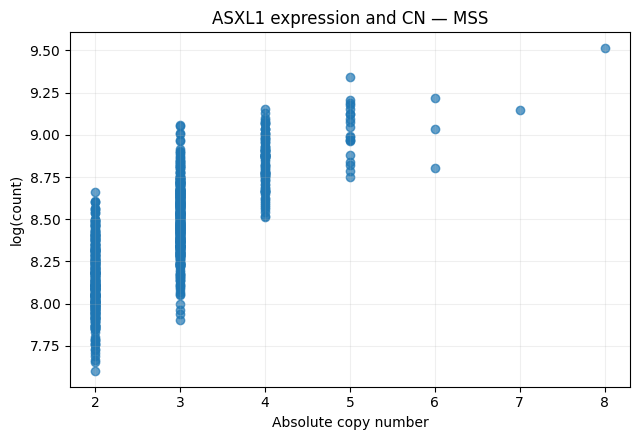

In [13]:
# Simple observed-data plot

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.scatter(
    gene_df["copies"],
    np.log1p(gene_df["expr"] / gene_df["sf"]),
    alpha=0.7,
)

ax.set_xlabel("Absolute copy number")
ax.set_ylabel("log(count)")
ax.set_title(f"{gene} expression and CN — {subtype}")
ax.grid(alpha=0.2)

fig.tight_layout()

## Fit BDGDM

Because the selected data contain one subtype, BDGDM uses the single-group model.

We use NUTS sampling to obtain posterior estimates. Variational inference can be used for rapid exploratory analyses, but NUTS is recommended
when accurate posterior uncertainty is required.

In [15]:
# Configure the fit
config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.95,
    return_ppc=False,
    save_draws=False,
    save_summary=False,
    seed=123
)

In [17]:
# Run BDGDM

model_single = CmdStanModel(stan_file="../bdgdm/stan/bdgdm_single.stan")

fit = fit_one_gene_bdgdm(
    gene_df=gene_df,
    gene="ASXL1",
    model_single=model_single,
    model_subtype=None,
    config=config,
)

16:39:41 - cmdstanpy - INFO - CmdStan start processing
16:39:41 - cmdstanpy - INFO - Chain [1] start processing
16:39:41 - cmdstanpy - INFO - Chain [2] start processing
16:39:41 - cmdstanpy - INFO - Chain [3] start processing
16:39:41 - cmdstanpy - INFO - Chain [4] start processing
16:40:01 - cmdstanpy - INFO - Chain [2] done processing
16:40:02 - cmdstanpy - INFO - Chain [3] done processing
16:40:05 - cmdstanpy - INFO - Chain [4] done processing
16:40:07 - cmdstanpy - INFO - Chain [1] done processing


## Posterior parameter estimates

The main BDGDM parameters are:

| Parameter | Interpretation |
|---|---|
| `b0` | Tumour component expression baseline at the diploid copy-number (CN=2) |
| `b_scaling` | Canonical response to proportional copy-number change |
| `b_deviation` | Deviation from the canonical copy-number trajectory |
| `b_noncancer_log` | Expression level of the non-cancer component |
| `phi` | Negative-binomial dispersion |

Posterior medians should always be interpreted together with their credible intervals.

In [19]:
posterior_summary = fit.posterior
metadata_df, parameter_summary, transition_summary = (
    get_posterior_summary_single(
        posterior_summary
    )
)

display(metadata_df)
display(parameter_summary.round(3))
display(transition_summary.round(3))

,analysis_mode,engine,n_subtypes,subtype
0,single_group,nuts,1,MSS


,parameter,subtype,median,q025,q975
0,b0,MSS,7.946,7.876,8.014
1,b_scaling,MSS,1.933,1.567,2.309
2,b_deviation,MSS,-0.228,-0.458,0.001
3,b_noncancer_log,None,8.375,8.330,8.420
4,phi,None,23.712,21.338,26.225


,transition,subtype,lp_median,lp_q025,lp_q975,fractional_change_median,fractional_change_q025,fractional_change_q975,p_positive,p_negative,p_rope,ppd,scaling_component_median,deviation_component_median,cancellation_index_median
0,2→1,MSS,-1.226,-1.382,-1.074,-0.707,-0.749,-0.658,0.0,1.0,0.0,1.0,-1.340,0.114,0.085
1,2→3,MSS,0.670,0.619,0.723,0.954,0.858,1.061,1.0,0.0,0.0,1.0,0.784,-0.114,-0.146
2,2→4,MSS,1.112,1.041,1.187,2.041,1.832,2.277,1.0,0.0,0.0,1.0,1.340,-0.228,-0.171


The posterior **b_scaling** coefficient is strongly positive and >>1, with a median of 1.93 and a 95% CI of 1.57–2.31. 
This indicates a stronger-than-proportional expression response to CNV. 

The posterior **b_deviation** coefficient is negative, suggesting partial attenuation of the canonical scaling response, although its CI narrowly included zero. 

Transition-level estimates indicated a 70.7% expression reduction for CN 2→1, a 95.4% increase for CN 2→3, and a 204.1% increase for CN 2→4. Directional posterior probabilities were equal to one for all three transitions.

## Model diagnostics

Posterior estimates should be interpreted only after checking sampling quality. 
We inspect split $\widehat{R}$, effective sample size, divergent transitions, tree depth, and the overall CmdStan diagnostic status.

In [21]:
diagnostics = fit.diagnostics

diagnostic_checks = get_nuts_diagnostics(
    diagnostics
)

diagnostic_checks

,check,value,passed
0,Overall diagnostic status,ok,True
1,Convergence flag,True,True
2,Maximum R-hat,1.002,True
3,Minimum bulk ESS,1440.37,True
4,Divergent transitions,0,True
5,Recorded warnings,0,True


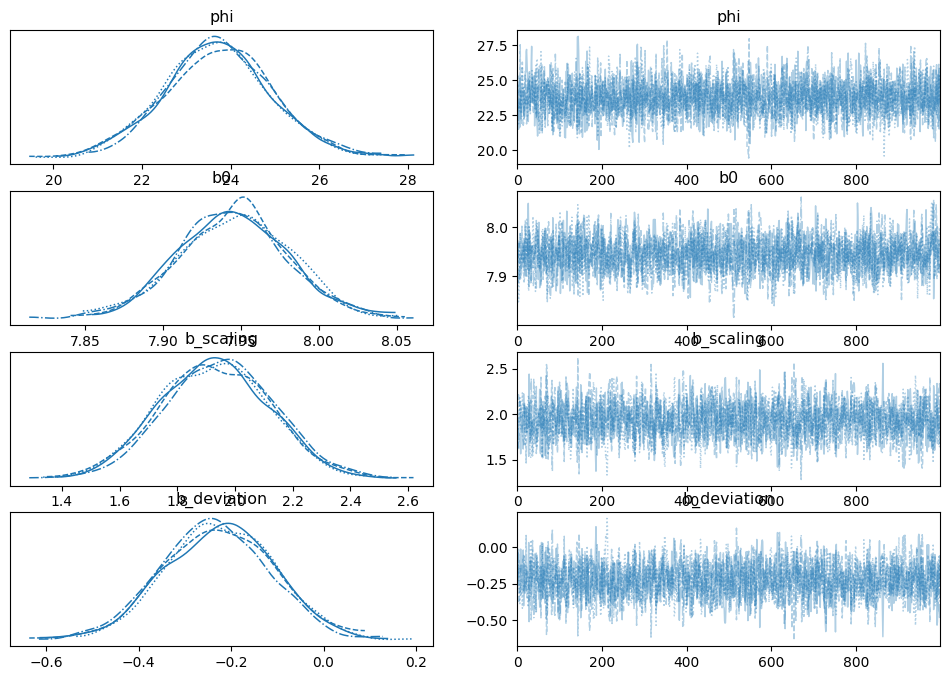

In [23]:
idata = az.from_cmdstanpy(posterior=fit.fit)
available = list(idata.posterior.data_vars)

az.plot_trace(
    idata,
    var_names=[
        "phi",
        "b0",
        "b_scaling",
        "b_deviation",
    ],
)

plt.show()

## Posterior predictive check

Posterior predictive checks (PPCs) compare the observed counts with counts generated from the fitted model.

Good agreement does not prove that the biological model is correct, but systematic discrepancies can reveal inadequate fit, unmodelled heterogeneity, or poorly represented copy-number states.

In [25]:
processed, stan_data, metadata = prepare_gene_data(
    gene_df=gene_df,
    gene="ASXL1",
    cna="all",
    et=0.15,
    min_aneup=5,
    min_unique_counts=5,
    min_cn_abs_sum=1.0,
)

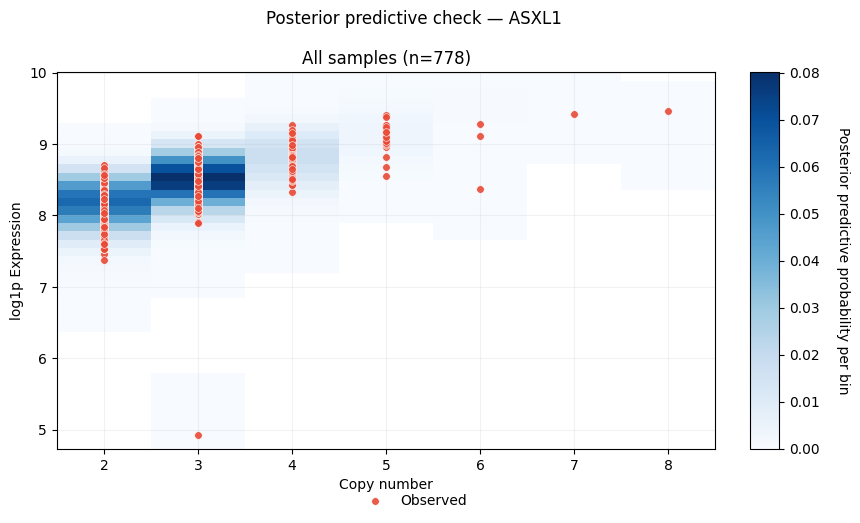

In [27]:
fig, axes, ppc_summary = plot_ppc_density(
    fit,
    x_observed=processed["copies"],
    y_observed=stan_data["y"],
    subtype_observed=None,
    subtype_order=None,
    gene="ASXL1",
    transform="log1p",
    x_bins="integer",
    density_mode="probability",
    figsize=(8.5, 5.7),
)

The posterior predictive distribution reproduced the overall increase in ASXL1 expression with increasing CN and covered most observed values at the well-represented CN states. 
One strong low-expression outlier is observed at CN=3. 
Predictions at CN = 5 - CN = 8 are less informative because these CN states contained relatively few samples.

## Classify the gene-dosage response

BDGDM combines posterior evidence for the scaling, deviation, and
copy-number-transition effects to assign a response class.

Possible outputs include:

- `DSG`: proportional dosage-sensitive response;
- `DCG`: attenuated or compensated response;
- `HYPER`: stronger-than-proportional response;
- `Mixed`: non-uniform or complex transition pattern;
- `DIG`: no supported within-tumour dosage response;
- `UNC`: insufficient posterior evidence for a confident classification.

In [29]:
# Define classification thresholds
thresholds = ClassificationThresholds(
    ppd_sig=0.95,
    rope_low=0.05,
    rope_high=0.95,
    dose_prob_sensitive=0.95,
    dose_prob_insensitive=0.95,
    cancel_threshold=0.20,
    overcomp_threshold=1.00,
    hyper_threshold=0.50,
    low_cn_aneup_threshold=5,
)

In [31]:
# Classify
classif = classify_fit(fit,
                      thresholds=thresholds)

subtype_result = get_subtype_classification(classif,
                                            subtype="MSS",
)

subtype_result

{'gene': 'ASXL1',
 'status': 'ok',
 'fit_flag': 'ok',
 'analysis_mode': 'single_group',
 'N': 778,
 'n_aneup': 478,
 'cna': 'all',
 'subtype_index': 1,
 'subtype': 'MSS',
 'response_class': 'HYPER',
 'response_reason': 'supported_hyper_pattern',
 'response_subclass': None,
 'b_scaling_median': 1.93277,
 'b_deviation_median': -0.228424,
 'p_deviation_small': 0.13725,
 'small_deviation': False,
 'small_deviation_method': 'posterior_probability',
 'dc_gain': False,
 'dc_loss': False,
 'dc_type': 'none'}

In [37]:
# Transition-level posterior evidence

transition_table = get_transition_df(classif)
transition_table

,gene,subtype_index,subtype,transition,transition_key,pattern,supported,null,support_method,fractional_change_median,direction_probability,rope_probability,ppd,response_ratio,hyper_supported,hyper_evidence_method,reverse_supported,cancellation_index
0,ASXL1,1,MSS,2→1,2to1,hyperactive,True,False,posterior_expected_direction,-0.707,1.0,0.0,1.0,1.769,True,credible_interval,False,0.085
1,ASXL1,1,MSS,2→3,2to3,hyperactive,True,False,posterior_expected_direction,0.954,1.0,0.0,1.0,1.652,True,credible_interval,False,-0.146
2,ASXL1,1,MSS,2→4,2to4,hyperactive,True,False,posterior_expected_direction,2.041,1.0,0.0,1.0,1.604,True,credible_interval,False,-0.171


ASXL1 displays a consistently stronger-than-proportional CN–expression response across the evaluated CN transitions. 
The deviation component provides modest attenuation, but the total transition effects remain credibly more than 50% stronger than the canonical proportional response.

## Interpretation

The final class should not be interpreted in isolation.

The conclusion should combine:

1. CN-state coverage in the observed data;
2. posterior estimates and credible intervals;
3. convergence diagnostics;
4. PPCs;
5. transition-level posterior evidence;
6. the final response class.

For example, a `DCG` classification indicates that the expression response is weaker than the canonical/proportional dosage expectation. Additional regulatory, epigenetic, or functional analyses are needed to identify potential molecular mechanisms.

An `UNC` result is an abstention rather than a biological class. It indicates that the available samples do not provide sufficient posterior evidence for a confident assignment.